# Radar tutorial 1 — fetch MRMS radar for NYC

**What you'll learn:** what the NOAA MRMS radar products are, how to fetch and cache
them for NYC with `src/fetch_data/mrms`, and how the 15-event catalog used in tutorials
2–3 is built.

**MRMS** (Multi-Radar/Multi-Sensor, NOAA/NSSL) mosaics every US radar onto a 0.01°
(~1 km) grid. We use three products:

| product | cadence | what it is |
|---|---|---|
| `MultiSensor_QPE_01H_Pass2` | 1 h | gauge-corrected hourly precipitation (mm) — **the reference** |
| `RadarOnly_QPE_01H` | 1 h | radar-only hourly precipitation (mm) — independent of every gauge |
| `PrecipRate` | 2 min | instantaneous rate (mm/h) |
| `PrecipFlag` | 2 min | surface precipitation type (rain / snow / …) |

Files come from the NOAA open-data bucket on AWS (anonymous, archive since Oct 2020),
with the Iowa Environmental Mesonet mirror as fallback. Only a small NYC crop of each
field is cached, under `dataset/raw/radar/mrms/cache/` (git-ignored).

**Requirements:** `eccodes` (in requirements) and internet for uncached fields.
§4 uses the full-period study files in `dataset/raw/full/outputs/` (local, not on Zenodo).

In [1]:
import sys, warnings
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
pd.set_option('display.width', 200, 'display.max_columns', 30)

REPO_ROOT = Path('..').resolve()
sys.path.insert(0, str(REPO_ROOT / 'src'))
from fetch_data.mrms import MRMSClient, NYC, PRODUCTS, PRECIP_FLAG, event_accumulation
from analysis import radar_utils as RU

## §1. Product registry

In [2]:
pd.DataFrame([dict(product=k, units=p.units, kind=p.kind, cadence=str(p.cadence),
                   description=p.description) for k, p in PRODUCTS.items()])

,product,units,kind,cadence,description
0,MultiSensor_QPE_01H_Pass2,mm,accumulation,1:00:00,"1-h gauge-corrected radar QPE, second pass (~6..."
1,MultiSensor_QPE_01H_Pass1,mm,accumulation,1:00:00,"1-h gauge-corrected radar QPE, first pass (~20..."
2,RadarOnly_QPE_01H,mm,accumulation,1:00:00,1-h radar-only QPE (no gauge correction).
3,MultiSensor_QPE_24H_Pass2,mm,accumulation,1:00:00,"24-h gauge-corrected QPE, second pass. Used to..."
4,PrecipRate,mm/h,rate,0:02:00,"Instantaneous surface precipitation rate, ever..."
5,PrecipFlag,category,category,0:02:00,"Surface precipitation type, every 2 min (see P..."
6,RadarQualityIndex,1,index,0:02:00,"Radar quality index 0..1 (beam blockage, heigh..."


## §2. One field: precipitation type during the 2026-01-25 blizzard

`client.read()` downloads, decodes and crops one file (no caching).
PrecipFlag codes are listed below; 3 = snow.

{0: 'none', 1: 'warm stratiform rain', 3: 'snow', 6: 'convective rain', 7: 'rain mixed with hail', 10: 'cool stratiform rain', 91: 'tropical/stratiform rain mix', 96: 'tropical/convective rain mix'}


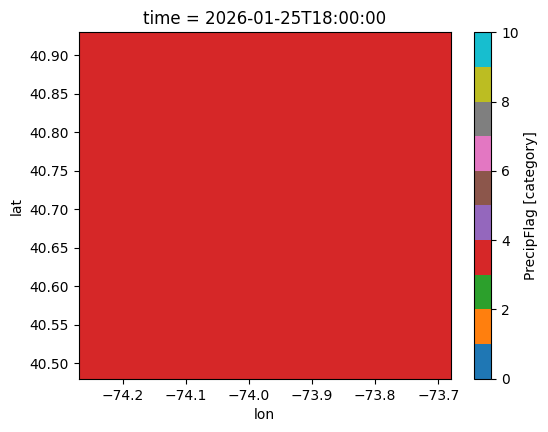

In [3]:
client = MRMSClient()
flag = client.read('PrecipFlag', '2026-01-25 18:00', NYC)
print(PRECIP_FLAG)
flag.isel(time=0).plot(figsize=(6, 4.5), cmap='tab10', vmin=0, vmax=10);

## §3. An event total from hourly QPE

`event_accumulation()` sums the hourly Pass-2 QPE over a window (hour-ending labels)
and keeps a per-cell `coverage` coordinate. The call fills the per-day cache, so a
second run is instant.

hours available: 24/24  domain mean: 72.0 mm  max: 96.6 mm


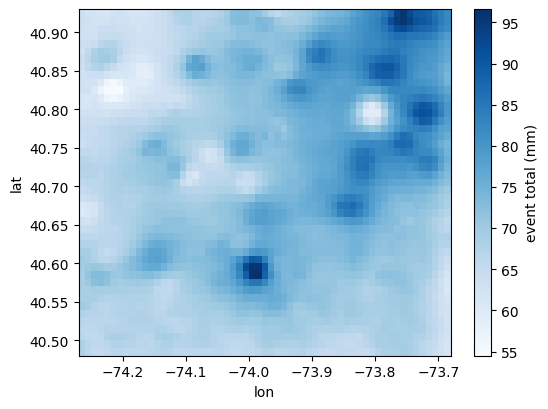

In [4]:
acc = event_accumulation('2024-03-23 00:00', '2024-03-24 00:00', NYC, client=client)
print(f"hours available: {acc.attrs['hours_available']}/{acc.attrs['hours_expected']}  "
      f"domain mean: {float(acc.mean()):.1f} mm  max: {float(acc.max()):.1f} mm")
acc.plot(figsize=(6, 4.5), cmap='Blues', cbar_kwargs={'label': 'event total (mm)'});

## §4. The 15-event catalog

`RU.build_event_catalog()` segments the ASOS network record into storms and keeps the
5 largest **snow**, **rain** and **mix** events of 2023-10-29 → 2026-04-23:

* phase from ASOS present-weather codes (share of wet station-minutes);
* magnitude from NOAA GHCN daily totals — snowfall (cm) for snow, precipitation (mm)
  for rain and mix — because automated gauges under-catch snow;
* "mix" must be cold (T ≤ 2 °C): warm "unknown-type" codes are thunderstorms.

The result is stored in `dataset/meta/radar_events.csv`; rebuilding it gives the same 15 events.

In [5]:
networks, cml, ghcn = RU.load_sensors()
events = RU.build_event_catalog(networks['ASOS'], ghcn)
assert events[['event', 'start', 'end']].equals(RU.load_event_catalog()[['event', 'start', 'end']])
events

  ASOS         5 stations
  WU PWS      80 stations
  Mesonet      4 stations
  CML        290 sublinks (120 ≥ 20 GHz)
  GHCN         4 stations (daily)


,event,cls,rank,start,end,hours,ghcn_mm,ghcn_snow_cm,asos_mm,t_min_C,f_rain,f_snow,f_frozen,f_P,n_stations
0,2026-02-22_snow,snow,1,2026-02-22 11:50:00,2026-02-24 03:20:00,39.500,49.100,55.350,12.141,-1.667,0.047,0.861,0.861,0.092,5
1,2026-01-25_snow,snow,2,2026-01-25 09:40:00,2026-01-27 07:40:00,46.000,35.425,27.700,27.330,-11.700,0.315,0.589,0.589,0.096,5
2,2025-12-26_snow,snow,3,2025-12-26 21:40:00,2025-12-27 19:10:00,21.500,11.725,10.725,8.763,-3.907,0.029,0.962,0.962,0.010,4
3,2024-02-17_snow,snow,4,2024-02-17 04:40:00,2024-02-17 18:50:00,14.167,6.800,9.975,5.944,-1.000,0.000,0.993,0.993,0.006,5
4,2024-02-13_snow,snow,5,2024-02-13 04:10:00,2024-02-13 18:10:00,14.000,16.775,9.900,16.967,0.311,0.141,0.805,0.805,0.054,5
5,2024-03-23_rain,rain,1,2024-03-23 00:40:00,2024-03-23 22:20:00,21.667,84.825,0.000,68.885,3.750,0.931,0.028,0.028,0.040,5
6,2024-04-01_rain,rain,2,2024-04-01 12:40:00,2024-04-04 15:10:00,74.500,70.050,0.000,57.861,2.833,0.832,0.019,0.019,0.150,5
7,2023-12-17_rain,rain,3,2023-12-17 18:00:00,2023-12-18 19:30:00,25.500,60.750,0.000,34.925,9.981,0.915,0.024,0.024,0.060,4
8,2024-08-06_rain,rain,4,2024-08-06 18:40:00,2024-08-10 05:30:00,82.833,59.975,0.000,69.901,18.472,0.849,0.002,0.002,0.149,5
9,2023-11-21_rain,rain,5,2023-11-21 14:30:00,2023-11-22 12:20:00,21.833,53.025,0.000,37.973,4.481,0.924,0.003,0.003,0.073,4


## §5. Fetch radar for all events

Same as running `python src/fetch_data/mrms/fetch_events.py` from the repo root: both
hourly QPEs plus 10-min PrecipFlag and PrecipRate, ±1 h around each event (8,712 fields,
~28 MB cached). Cached fields are not downloaded again.

In [6]:
summary = RU.fetch_event_radar(events, verbose=False)
summary.pivot(index='event', columns='product', values='n_fields')

product,MultiSensor_QPE_01H_Pass2,PrecipFlag,PrecipRate,RadarOnly_QPE_01H
event,,,,
2023-11-21_rain,26,151,151,26
2023-12-17_rain,29,169,169,29
2024-01-06_mix,32,187,187,32
2024-02-13_snow,18,103,103,18
2024-02-17_snow,18,103,103,18
2024-03-09_mix,87,517,517,87
2024-03-23_rain,26,151,151,26
2024-04-01_rain,79,469,469,79
2024-08-06_rain,87,517,517,87


**Next:** [radar tutorial 2](radar_02_merge_sensors.ipynb) — put every sensor next to the radar.